# Обучение детектора чека на YOLOv8

В этом ноутбуке мы дообучаем детектор, который находит чек на фотографии. Это первый из обучаемых нейросетевых компонентов системы. Его задача - локализовать чек на произвольном фоне, чтобы дальше можно было выправить перспективу и подать ровный, обрезанный чек в модель распознавания.

За основу берём YOLOv8. Учить с нуля смысла нет, поэтому мы дообучаем её под один новый класс - чек. Данные для обучения это около сотни фотографий чеков с размеченными рамками, расширенные нашими аугментациями под реальные условия съёмки: наклоны, блики, шум, разную яркость.

Обучение идёт в Colab на GPU, потому что на процессоре это заметно медленнее. Если переобучать не хочется, в ячейке настройки ниже можно включить режим, когда обучение пропускается, а готовые веса просто скачиваются. В итоге получаем обученный детектор с измеренным качеством.

## Запуск в Google Colab

Ноутбук я специально подготовила для удобного запуска в Colab без ручных скачиваний.
Код и данные подтягиваются из удалённых источников автоматически.

Важно: если хотите пропустить этап обучения просто Поставьте True в ячейке ниже в соответствующую перемнную, там помечено комментарием, какую именно. Тогда просто удалённо подтянутся веса нужной модели, вообще все веса итоговых моделей залиты на Google Drive.

In [1]:
import os
import sys
import subprocess
from pathlib import Path
import zipfile
import gdown

IN_COLAB = "google.colab" in sys.modules
# Публичный git-репозиторий с кодом проекта
REPO_URL = "https://github.com/ScarletFlame611/Receipt-AI.git"
# id датасета детектора
DETECTOR_GDRIVE_ID = "1pa9nGYgRNzlT3iMUNRfAxeOqfmCqT-rm"
# id итоговых готовых весов детектора
DETECTOR_WEIGHTS_GDRIVE_ID = "114yEv9vKNS9uoIJrCwzvPTAzXau2KxGQ"

# Пропустить обучение и взять готовые веса с Google Drive
SKIP_TRAINING = True


def _find_project_root():
    here = Path.cwd()
    for cand in [here, *here.parents]:
        if (cand / "src").is_dir():
            return cand
    for sub in sorted(p for p in here.iterdir() if p.is_dir()):
        if (sub / "src").is_dir():
            return sub
    return None


if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "-q", "install",
         "ultralytics", "albumentations", "gdown"],
        check=False,
    )
    if _find_project_root() is None and "USER/" not in REPO_URL:
        subprocess.run(["git", "clone", REPO_URL], check=True)

for _m in [m for m in sys.modules if m == "src" or m.startswith("src.")]:
    del sys.modules[_m]
root = _find_project_root()
if root is None:
    raise RuntimeError(
        "Не найден код проекта"
    )
os.chdir(root)
sys.path.insert(0, str(root))
print("Colab:", IN_COLAB, "| корень проекта:", root, "| SKIP_TRAINING:", SKIP_TRAINING)


def ensure_detector(root):
    target = Path(root) / "data" / "processed" / "detector"
    imgs = target / "train" / "images"
    if imgs.is_dir() and any(imgs.glob("*.jpg")):
        return target
    target.parent.mkdir(parents=True, exist_ok=True)
    zip_path = target.parent / "detector.zip"
    print("detector не найден локально, качаем с Google Drive")
    gdown.download(id=DETECTOR_GDRIVE_ID, output=str(zip_path), quiet=False)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(target.parent)
    zip_path.unlink()
    print("Готово:", target)
    return target


def ensure_detector_weights(root):
    dst = Path(root) / "weights" / "detector" / "best.pt"
    if dst.exists():
        return dst
    dst.parent.mkdir(parents=True, exist_ok=True)
    print("Качаем готовые веса детектора с Google Drive")
    gdown.download(id=DETECTOR_WEIGHTS_GDRIVE_ID, output=str(dst), quiet=False)
    return dst

Colab: True | корень проекта: /content/Receipt-AI | SKIP_TRAINING: True


In [2]:
import torch

print("GPU доступен:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Устройство:", torch.cuda.get_device_name(0))

GPU доступен: True
Устройство: Tesla T4


In [3]:
!pip install ultralytics albumentations -q

## Загрузка датасета детектора

Датасет детектора скачивается с Google Drive (если его ещё нет локально).
Обученные веса и графики сохраняются локально в сессии Colab.


In [4]:
from pathlib import Path
ensure_detector(root)

detector не найден локально, качаем с Google Drive


Downloading...
From (original): https://drive.google.com/uc?id=1pa9nGYgRNzlT3iMUNRfAxeOqfmCqT-rm
From (redirected): https://drive.google.com/uc?id=1pa9nGYgRNzlT3iMUNRfAxeOqfmCqT-rm&confirm=t&uuid=30a9b80d-c33b-4d88-9bc6-725ca758cdbc
To: /content/Receipt-AI/data/processed/detector.zip
100%|██████████| 64.9M/64.9M [00:00<00:00, 107MB/s]


Готово: /content/Receipt-AI/data/processed/detector


PosixPath('/content/Receipt-AI/data/processed/detector')

In [5]:
from pathlib import Path

data_root = root / "data" / "processed" / "detector"
print("Папка датасета существует:", data_root.exists())
for split in ["train", "valid", "test"]:
    img_dir = data_root / split / "images"
    if img_dir.exists():
        n = len(list(img_dir.glob("*.jpg")))
        print(f"{split}: {n} картинок")
    else:
        print(f"{split}: папки нет")

Папка датасета существует: True
train: 690 картинок
valid: 39 картинок
test: 21 картинок


## Конфигурация датасета для YOLO

YOLO читает пути к данным из файла data.yaml. Создаём конфиг заново, уже с путями Colab.

In [6]:
yaml_path = data_root / "data_colab.yaml"
yaml_text = (
    f"train: {(data_root / 'train' / 'images').as_posix()}\n"
    f"val: {(data_root / 'valid' / 'images').as_posix()}\n"
    f"test: {(data_root / 'test' / 'images').as_posix()}\n"
    f"nc: 1\n"
    f"names: ['Receipt']\n"
)
yaml_path.write_text(yaml_text)
print(yaml_text)
print("Конфиг записан:", yaml_path)

train: /content/Receipt-AI/data/processed/detector/train/images
val: /content/Receipt-AI/data/processed/detector/valid/images
test: /content/Receipt-AI/data/processed/detector/test/images
nc: 1
names: ['Receipt']

Конфиг записан: /content/Receipt-AI/data/processed/detector/data_colab.yaml


## Аугментации данных

Перед обучением посмотрим, как выглядят аугментации, которыми мы расширили обучающую выборку. Из каждой исходной фотографии генерируется несколько искажённых вариантов: с наклоном, изменённой яркостью, перспективными искажениями, шумом и бликами. Это учит детектор узнавать чек в разных условиях съёмки, а не только на идеальных кадрах. Рамка объекта при этом пересчитывается синхронно с изображением.

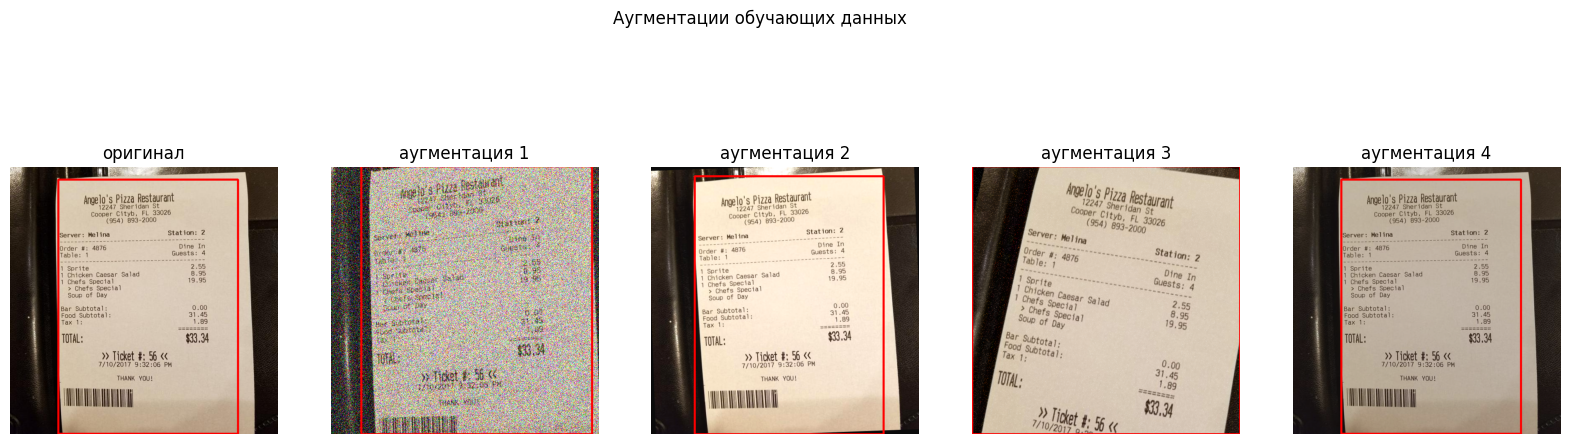

In [27]:
import cv2
import random
import albumentations as A
import matplotlib.pyplot as plt

pipeline = A.Compose(
    [
        A.Rotate(limit=12, border_mode=0, p=0.7),
        A.Perspective(scale=(0.02, 0.08), p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.6),
        A.OneOf([A.GaussNoise(p=1.0), A.ISONoise(p=1.0)], p=0.4),
        A.OneOf([A.MotionBlur(blur_limit=5, p=1.0), A.GaussianBlur(blur_limit=5, p=1.0)], p=0.3),
        A.RandomSunFlare(flare_roi=(0, 0, 1, 1), src_radius=120, p=0.2),
    ],
    bbox_params=A.BboxParams(format="yolo", min_visibility=0.3, label_fields=["class_labels"]),
)

img_dir = data_root / "train" / "images"
lbl_dir = data_root / "train" / "labels"
originals = [p for p in img_dir.glob("*.jpg") if "_aug" not in p.name]
sample_path = random.choice(originals)
image = cv2.cvtColor(cv2.imread(str(sample_path)), cv2.COLOR_BGR2RGB)
lines = (lbl_dir / (sample_path.stem + ".txt")).read_text().strip().splitlines()
bboxes = [list(map(float, l.split()))[1:] for l in lines]
classes = [int(l.split()[0]) for l in lines]

def draw(img, boxes):
    out = img.copy()
    h, w = out.shape[:2]
    for cx, cy, bw, bh in boxes:
        x1, y1 = int((cx - bw/2)*w), int((cy - bh/2)*h)
        x2, y2 = int((cx + bw/2)*w), int((cy + bh/2)*h)
        cv2.rectangle(out, (x1, y1), (x2, y2), (255, 0, 0), 3)
    return out

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
axes[0].imshow(draw(image, bboxes)); axes[0].set_title("оригинал"); axes[0].axis("off")
for i in range(1, 5):
    r = pipeline(image=image, bboxes=bboxes, class_labels=classes)
    axes[i].imshow(draw(r["image"], r["bboxes"])); axes[i].set_title(f"аугментация {i}"); axes[i].axis("off")
plt.suptitle("Аугментации обучающих данных")
plt.show()

Мы видим отличный результат, аугментации применились, изображения разные, где-то угол наклона, где-то шум и т.д., то есть в целом похоже на разные условии фотографий. И при этом рамка жействителньо на каждой фотке правильно пересчиталась. Даже на 3 аугментации где чтобы захватить чек нужно выжелить вообще всю фотографию. С такими жанными можно приступать к обучению.

## Обучение детектора

Запускаем дообучение YOLOv8. За основу берём YOLOv8n, самую лёгкую версию. Её достаточно для одного простого класса, она быстро обучается
и работает даже на CPU при инференсе.

Веса и графики сохраняются локально в сессии Colab, с ранней остановкой (если
качество на валидации не растёт 15 эпох). Если выставить `SKIP_TRAINING = True`
в ячейке настройки, обучение пропускается и берутся готовые веса с Google Drive.

In [ ]:
import shutil
from ultralytics import YOLO

project_dir = str(root / "runs" / "detector")
run_dir = root / "runs" / "detector" / "receipt_yolo"

if SKIP_TRAINING:
    best_weights = ensure_detector_weights(root)
    print("Обучение пропущено. Готовые веса:", best_weights)
else:
    model = YOLO("yolov8n.pt")
    model.train(
        data=str(yaml_path),
        epochs=60,
        imgsz=640,
        batch=16,
        project=project_dir,
        name="receipt_yolo",
        patience=15,
        plots=True,
    )
    best_weights = run_dir / "weights" / "best.pt"

    out_dir = root / "assets" / "detector"
    out_dir.mkdir(parents=True, exist_ok=True)
    for name in ["results.png", "confusion_matrix.png"]:
        if (run_dir / name).exists():
            shutil.copy(run_dir / name, out_dir / name)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/receipt-ai/detector/data/processed/detector/data_colab.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=N

## Результаты обучения

Обучение остановилось на 52 эпохе ранней остановкой, лучшая модель зафиксирована на 37 эпохе. На валидации детектор показал точность 0.972, полноту 1.0, mAP50 0.995 и mAP50-95 0.839.

YOLO во время обучения сама сохранила графики: кривые функций потерь и метрик по эпохам, матрицу ошибок, примеры предсказаний. Посмотрим их.

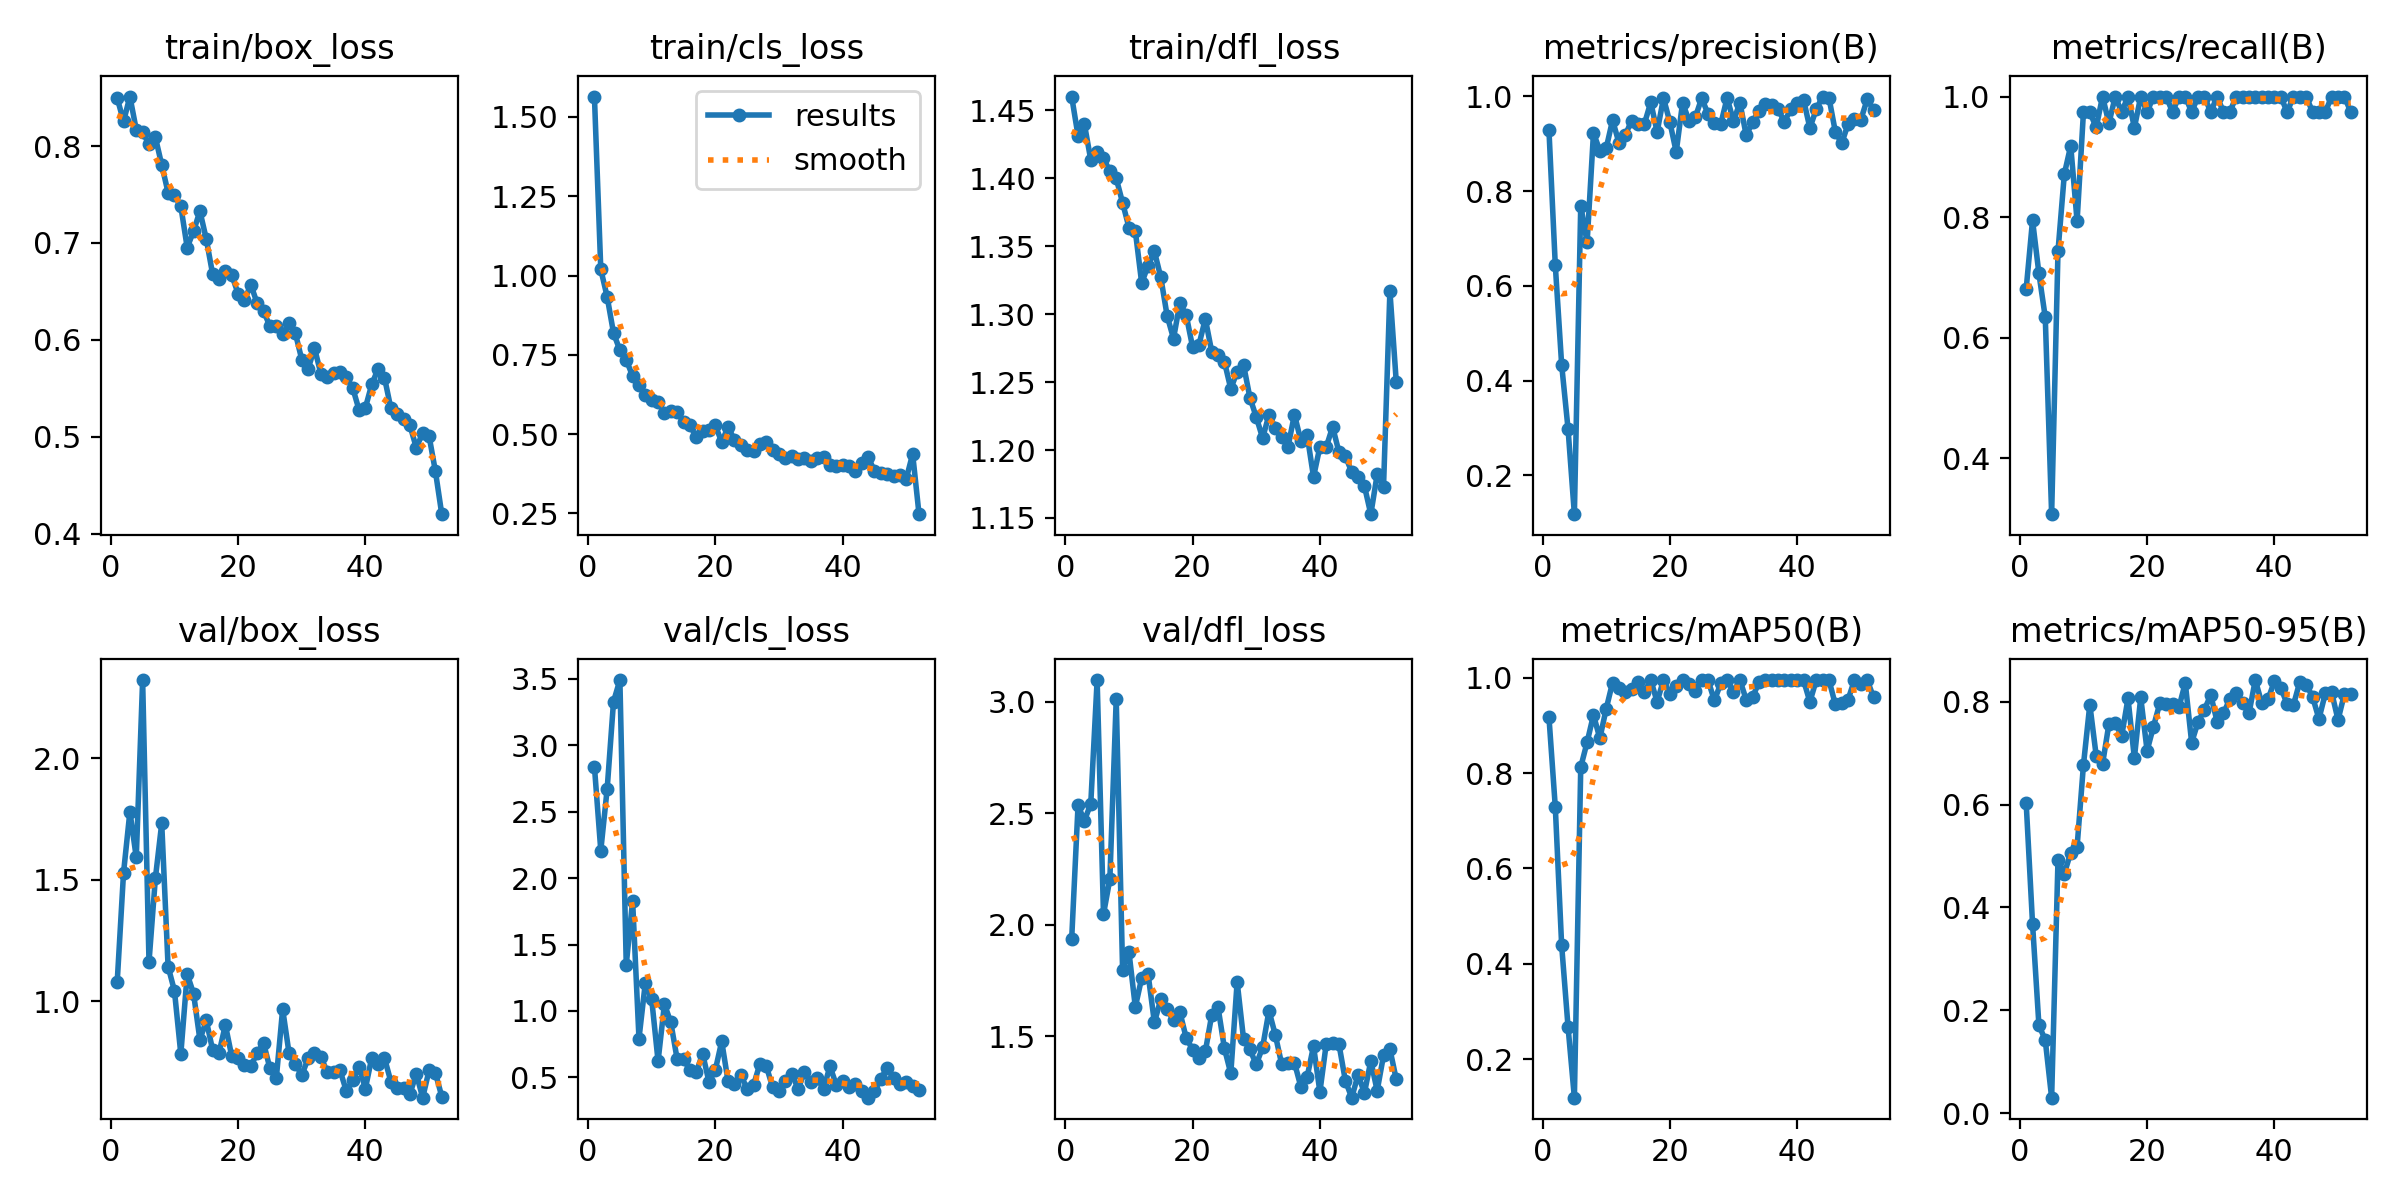

In [7]:
from IPython.display import Image as IPImage, display

run_dir = root / "runs" / "detector" / "receipt_yolo"
plots_dir = root / "assets" / "detector"


def show_plot(name):
    path = run_dir / name if (run_dir / name).exists() else plots_dir / name
    if path.exists():
        display(IPImage(str(path)))
    else:
        print("нет файла:", name)


show_plot("results.png")


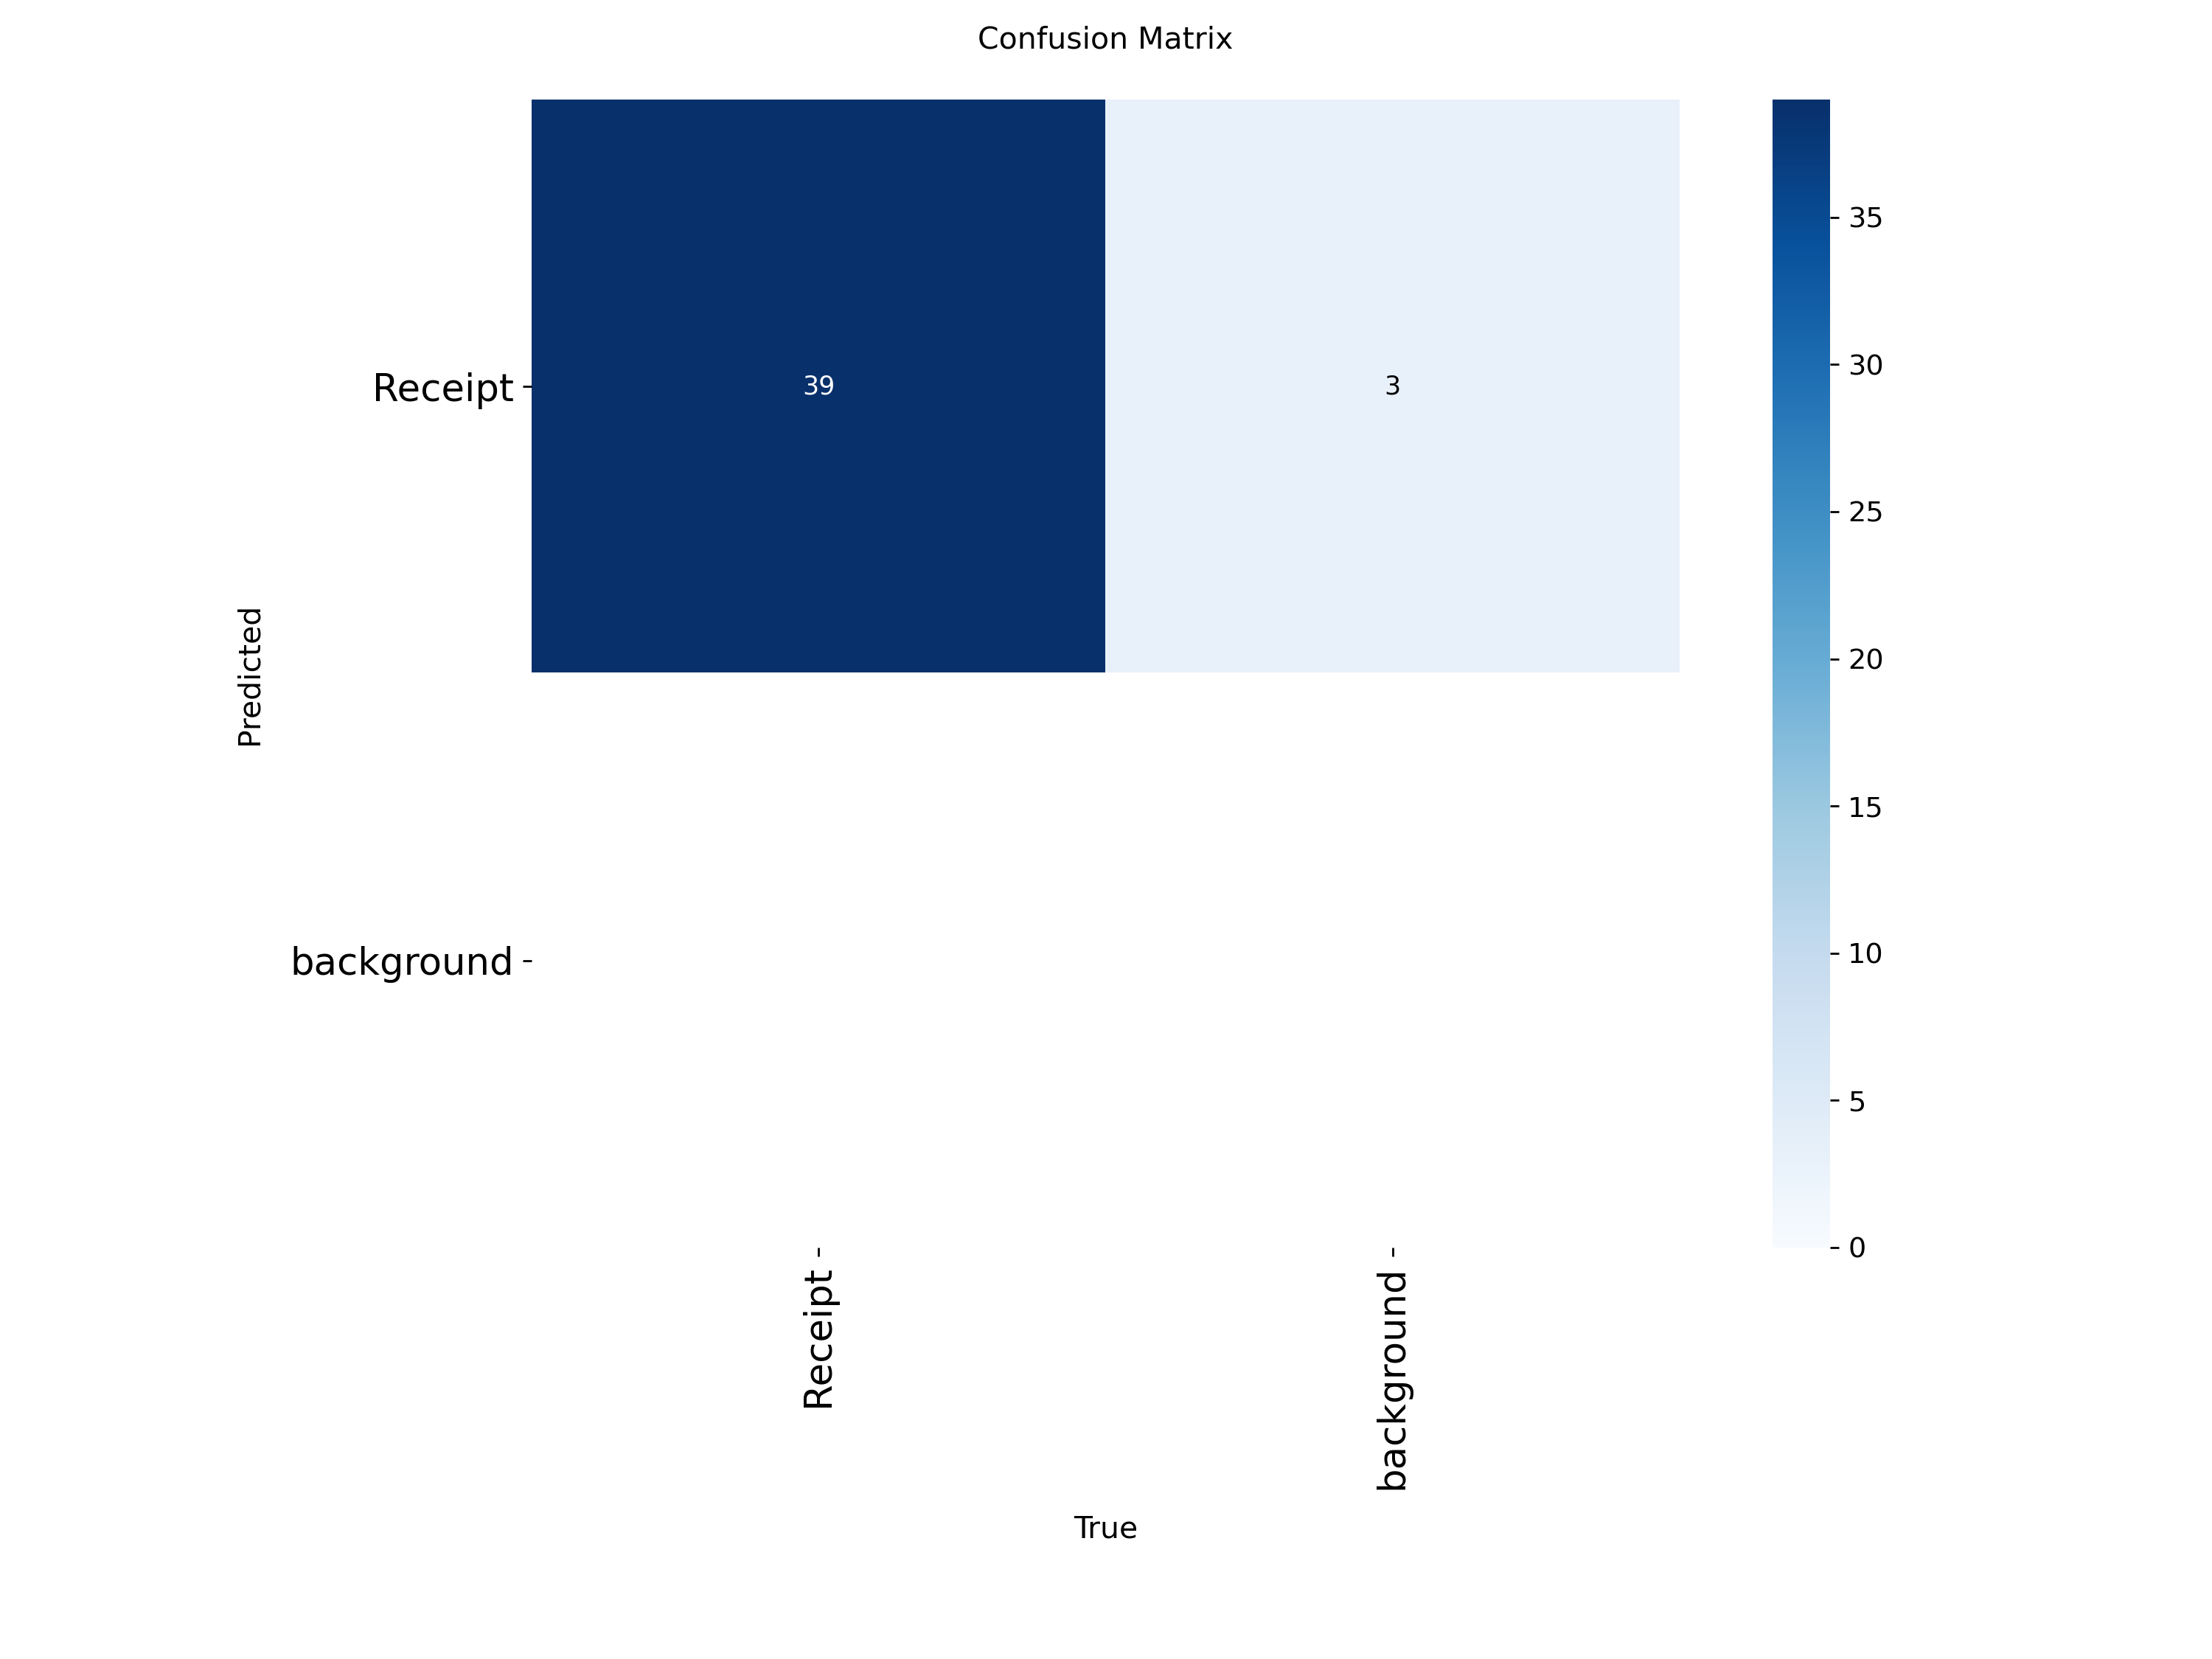

In [8]:
show_plot("confusion_matrix.png")


Графики подтверждают нормальное обучение. Все функции потерь, и на обучающей выборке, и на валидационной, последовательно убывают и выходят на плато. Ключевой признак отсутствия переобучения в том, что валидационные потери падают вместе с обучающими и не начинают расти обратно. Метрики точности, полноты и mAP быстро поднимаются в первые двадцать эпох и дальше держатся у максимума.

Матрица ошибок показывает, что все тридцать девять чеков на валидации найдены верно, пропусков нет. Три раза модель приняла за чек посторонний фон, и именно эти ложные срабатывания дают точность 0.972 вместо единицы. Для нашей задачи такая ошибка некритична: лишняя рамка на фоне менее опасна, чем пропущенный чек, и легко отсекается порогом уверенности при инференсе.

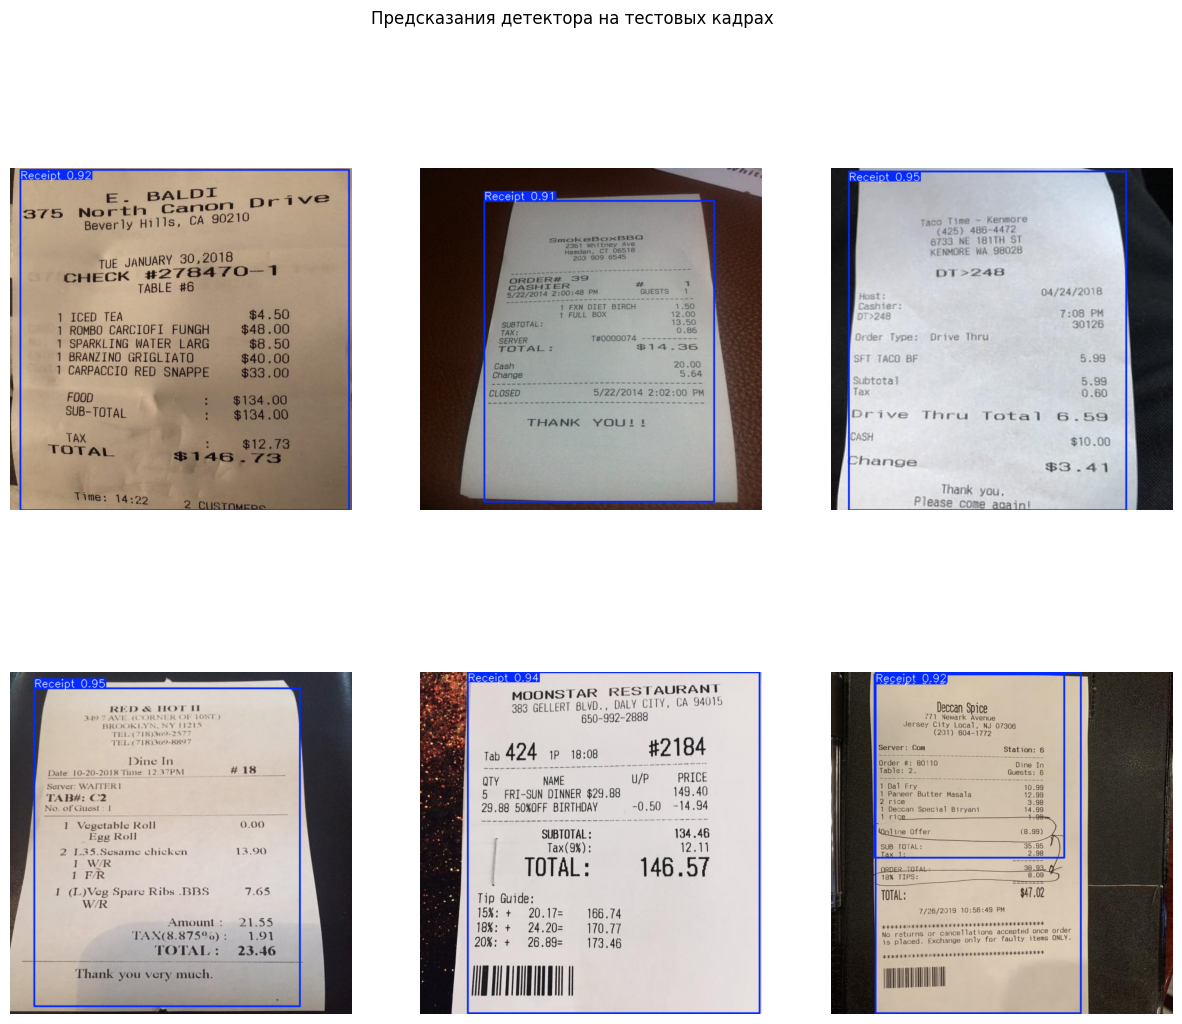

In [28]:
from ultralytics import YOLO

best_weights = ensure_detector_weights(root)
model = YOLO(str(best_weights))

test_images = sorted((data_root / "test" / "images").glob("*.jpg"))
sample_test = random.sample(test_images, min(6, len(test_images)))
fig, axes = plt.subplots(2, 3, figsize=(15, 12))
for ax, img_path in zip(axes.ravel(), sample_test):
    res = model(str(img_path), verbose=False)[0]
    annotated = res.plot()
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    ax.imshow(annotated)
    ax.axis("off")
plt.suptitle("Предсказания детектора на тестовых кадрах")
plt.show()


Проверка на тестовых кадрах, которые модель не видела ни при обучении, ни при валидации, подтверждает хорошее качество детектора. На всех чеках рамка найдена и точно обводит чек, уверенность высокая, от 0.91 до 0.95. Чеки сняты в разных условиях, на тёмном и светлом фоне, под наклоном и прямо, и везде детекция сработала.

На одном кадре видна слабая лишняя рамка с уверенностью 0.25 на краю соседнего предмета. Это та самая редкая ошибка ложного срабатывания на фоне, что мы видели в матрице ошибок. Решается она просто: при инференсе мы отсекаем предсказания ниже порога уверенности, и тогда настоящие чеки с уверенностью выше 0.9 остаются, а слабые ложные срабатывания отбрасываются. Этот порог мы заложим в обёртку детектора.

Итак, детектор готов. Лучшие веса лежат в weights/detector и дальше используются в пайплайне.

1120-receipt_jpg.rf.9be71a37c39bb099692a7a45cf360052.jpg: метод = yolo, размер обрезки = (595, 497, 3)


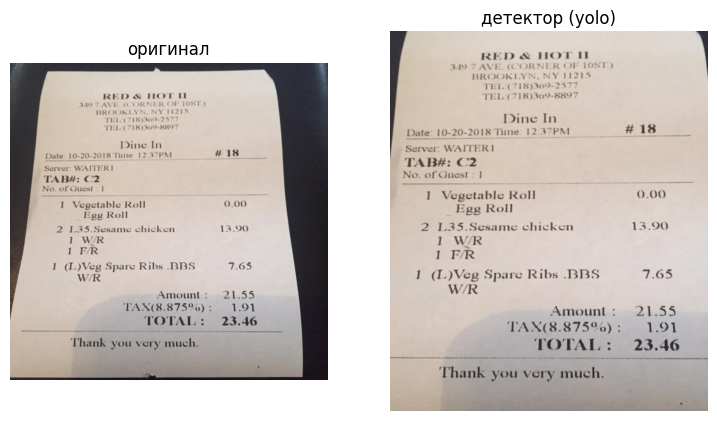

1093-receipt_jpg.rf.bc718f1b96dc3a642c72f2b0ae6e956d.jpg: метод = yolo, размер обрезки = (602, 624, 3)


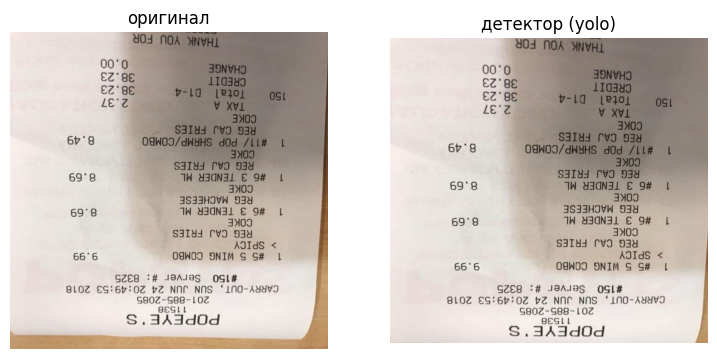

In [29]:
import shutil
import importlib
from pathlib import Path
import src.models.detector
from src.utils.io import cv_to_pil
from src.models.detector import ReceiptDetector

weights_dst = root / "weights" / "detector"
weights_dst.mkdir(parents=True, exist_ok=True)
if Path(best_weights).resolve() != (weights_dst / "best.pt").resolve():
    shutil.copy(best_weights, weights_dst / "best.pt")
importlib.reload(src.models.detector)
detector = ReceiptDetector()
sample = random.sample(sorted((data_root / "test" / "images").glob("*.jpg")), 2)
for img_path in sample:
    img = cv2.imread(str(img_path))
    crop, method = detector.detect(img)
    print(f"{img_path.name}: метод = {method}, размер обрезки = {crop.shape}")
    fig, axes = plt.subplots(1, 2, figsize=(9, 7))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title("оригинал"); axes[0].axis("off")
    axes[1].imshow(cv_to_pil(crop)); axes[1].set_title(f"детектор ({method})"); axes[1].axis("off")
    plt.show()
